In [141]:
import scanpy as sc
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

# Calculate traits and covs based on Matrix D1 and D1D2 proportions

Bican h5ad have been generated using `/home/gdallagl/myworkdir/XDP/script/multiple_samples_analysis/find_spatial_grad_gene_MSN_types.ipynb`

### Load adatas

In [24]:
msn_type_path_dict = {
    "eMSN_D1D2": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_eMSN_D1D2_Matrix.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, #gs://macosko_data/akraft/Zonal_Objects/
    # "Patch_D1": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D1_Patch_MSN.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, # gs://macosko_data/akraft/Zonal_Objects/
    # "Patch_D2": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D2_Patch_MSN.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, # gs://macosko_data/akraft/Zonal_Objects/
    "Matrix_D1": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D1_Matrix_MSN.qs", "zone_col": "D1_Matrix_Zone", "donor_col": "donor", "x": "x_position", "y": "y_position"},# gs://macosko_data/akraft/Human_Striatum_Slide-tags/High_Quality_by_Celltype/
    #"Matrix_D2": {"path": "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/STR_D2_Matrix_MSN.qs", "zone_col": "D2_Matrix_Zone", "donor_col": "donor", "x": "x_position", "y": "y_position"}, #gs://macosko_data/akraft/Human_Striatum_Slide-tags/High_Quality_by_Celltype/
}

In [53]:
d1d2 = sc.read_h5ad('/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/eMSN_D1D2.h5ad')

d1d2_samples = d1d2.obs["donor_id"].unique().tolist()

processed = []
for cell_type, infos in list(msn_type_path_dict.items())[:]:

    print(cell_type)

    if cell_type == "eMSN_D1D2":
        processed.append(d1d2)
    else:
        adata = sc.read_h5ad(f'/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/{cell_type}.h5ad', backed='r')
        print(adata)
        print(adata.obs["donor_id"].value_counts())
        adata = adata[adata.obs["donor_id"].isin(d1d2_samples), :].to_memory().copy()  # keep only donors that are in eMSN_D1D2

        processed.append(adata)

# concat
adata = sc.concat(processed)
adata.obs_names_make_unique()
adata.obs["ct"] = adata.obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN_D1D2", "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch"
})

adata.layers["counts"] = adata.X.copy()  # store raw counts in a separate layer


eMSN_D1D2
Matrix_D1
AnnData object with n_obs × n_vars = 47008 × 37905 backed at '/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/Matrix_D1.h5ad'
    obs: 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_label', 'Neighborhood_name', 'Class_label', 'Class_name', 'Subclass_label', 'Subclass_name', 'Group_label', 'Group_name', 'nCount_RNA', 'nFeature_RNA', 'library', 'donor', 'unique_cell_ID', 'celltype', 'x_position', 'y_position', 'Zone', 'D1_Matrix_Zone', 'D2_Matrix_Zone', 'Spatially_Placed', 'donor_id', 'x', 'y', 'zone', 'ct_for_deg'
    obsm: 'spatial'
donor_id
s23    5242
s37    4180
s31    4140
s38    3479
s5     3396
s35    3037
s12    2800
s15    2745
s26    2352
s16    1971
s34    1919
s32    1800
s36    1743
s17    1657
s21    1628
s33    1622
s29    1374
s18    1228
s20     695
Name: count, dtype: int64


In [54]:
# Need to add ids

# # mapping between donors ids versiosn
# a = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/D1_matrix_6_clusters_no56.h5ad", backed="r")
# obs = a.obs[["donor", "donor_id"]].dropna().drop_duplicates().set_index("donor_id").copy()
# obs = obs[obs.index != "nan"]
# obs.to_csv("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/spatial_bican_ids_conversion.csv")

ids_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/spatial_bican_ids_conversion.csv")
ids_df

adata.obs.drop(columns=["donor_id"], inplace=True)
adata.obs = adata.obs.merge(ids_df, left_on="donor", right_on="donor", how="left")

adata = adata[~adata.obs["donor_id"].isna(), :].copy()  # remove cells with no donor_id

adata.obs[["donor_id", "donor"]].drop_duplicates().sort_values("donor_id")

/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


,donor_id,donor
4791,MD6927,s36
3148,MD9129,s29
3318,MD9162,s31
4561,MD9261,s35
3041,MS30499,s26
1707,MS706984,s17
5009,MS876075,s37
1954,MS913848,s18
2625,MS9244,s23
5496,MS986638,s38


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


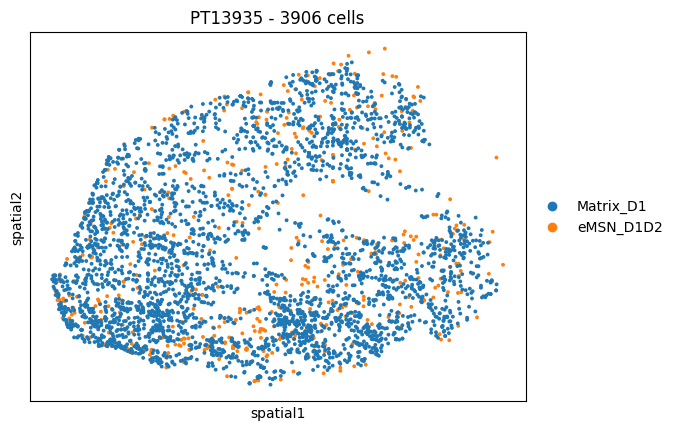

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


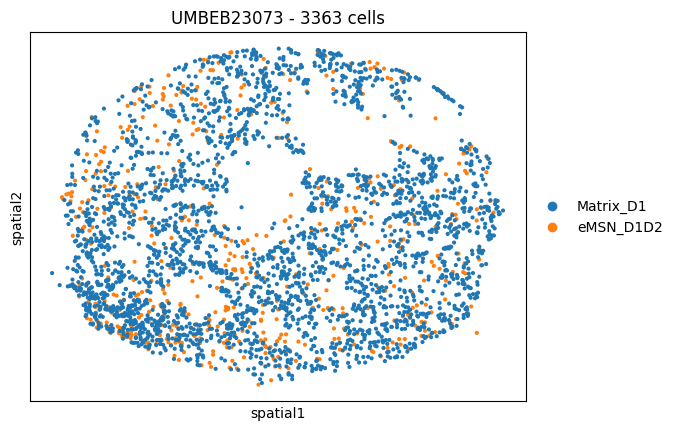

In [55]:
for s in adata.obs["donor_id"].unique()[:2]:
    sc.pl.embedding(adata[adata.obs["donor_id"] == s], basis="spatial", color=["ct_for_deg"], title=f"{s} - {adata[adata.obs['donor_id'] == s].shape[0]} cells")
    #break

### Calcutle trait

In [61]:
df_meta = adata.obs.drop_duplicates("donor_id").set_index("donor_id")[["experiment"]]
df_meta["m1_z1_raw_trait"] = np.nan
df_meta["m1_z1_trait"] = np.nan
df_meta["d1d1_z2_cov"] = np.nan

df_meta

,experiment,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov
donor_id,,,,
PT13935,s5,NaN,NaN,NaN
UMBEB23073,s12,NaN,NaN,NaN
UMBEB23033,s15,NaN,NaN,NaN
UMBEB23076,s16,NaN,NaN,NaN
MS706984,s17,NaN,NaN,NaN
MS913848,s18,NaN,NaN,NaN
UMBEB22074,s20,NaN,NaN,NaN
UMBEB23127,s21,NaN,NaN,NaN
MS9244,s23,NaN,NaN,NaN


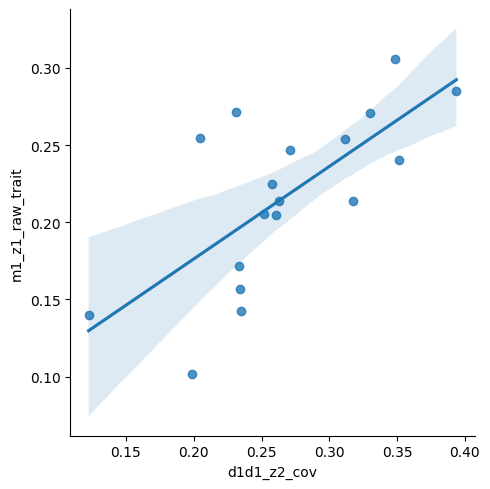

,experiment,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,
PT13935,s5,0.204653,-0.500904,0.260784,3396.0
UMBEB23073,s12,0.271071,1.063244,0.230906,2800.0
UMBEB23033,s15,0.205100,-0.350415,0.252199,2745.0
UMBEB23076,s16,0.213597,-0.207504,0.317406,1971.0
MS706984,s17,0.101388,-1.821749,0.198381,1657.0
MS913848,s18,0.224756,0.068729,0.257732,1228.0
UMBEB22074,s20,0.284892,1.346683,0.393701,695.0
UMBEB23127,s21,0.213759,-0.068729,0.262857,1628.0
MS9244,s23,0.254292,0.663752,0.204327,5242.0


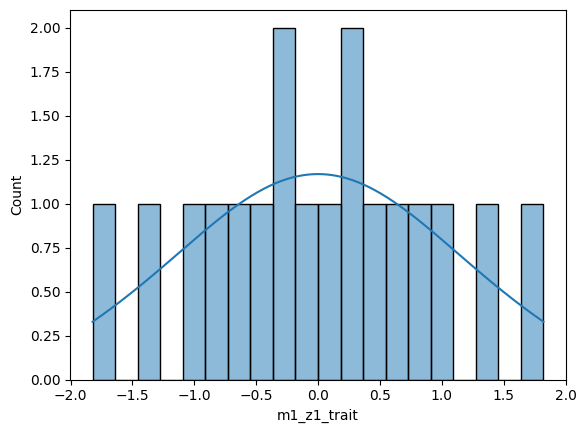

In [68]:
import numpy as np
from scipy.stats import norm

def rint(series):
    """Rank-based inverse-normal transform (Blom), NaN-safe."""
    x = series.copy()
    mask = x.notna()                      # ignore donors with no value
    ranks = x[mask].rank(method="average")
    n = mask.sum()
    # Blom offset c = 3/8 is the standard choice
    x[mask] = norm.ppf((ranks - 3/8) / (n - 2*3/8 + 1))
    return x

for donor in df_meta.index:

    obs_donor = adata[adata.obs["donor_id"] == donor].obs

    n_m1_total = len(obs_donor[obs_donor["ct_for_deg"] == "Matrix_D1"])
    n_m1_z1    = len(obs_donor[(obs_donor["ct_for_deg"] == "Matrix_D1") & (obs_donor["zone"] == 1)])

    n_espn_total = len(obs_donor[obs_donor["ct_for_deg"] == "eMSN_D1D2"])
    n_espn_z1    = len(obs_donor[(obs_donor["ct_for_deg"] == "eMSN_D1D2") & (obs_donor["zone"] == 1)])

    # guard against donors with zero matrix-D1 cells -> NaN instead of crash
    df_meta.loc[donor, "n_m1_total"]        = n_m1_total
    df_meta.loc[donor, "m1_z1_raw_trait"]   = n_m1_z1 / n_m1_total if n_m1_total > 0 else np.nan
    df_meta.loc[donor, "d1d1_z2_cov"]       = n_espn_z1 / n_espn_total if n_espn_total > 0 else np.nan

# AFTER the loop: transform the whole column at once
df_meta["m1_z1_trait"] = rint(df_meta["m1_z1_raw_trait"])

# add to adata.obs
adata.obs = adata.obs.merge(df_meta[["m1_z1_trait", "m1_z1_raw_trait", "d1d1_z2_cov"]], left_on="donor_id", right_index=True, how="left")   

sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait"); plt.show()
sns.histplot(data=df_meta, x="m1_z1_trait", bins=20, kde=True)
df_meta

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


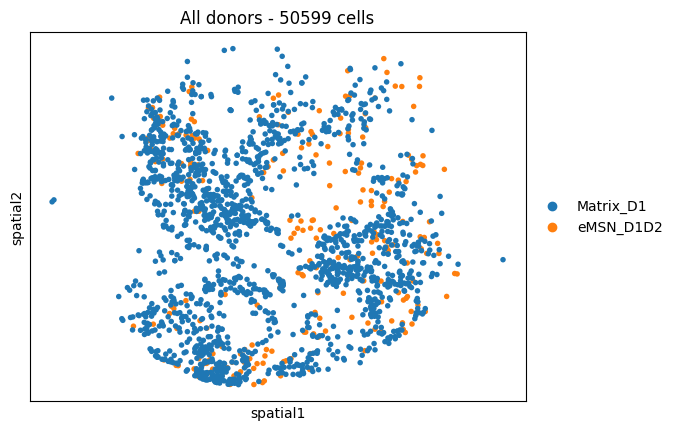

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


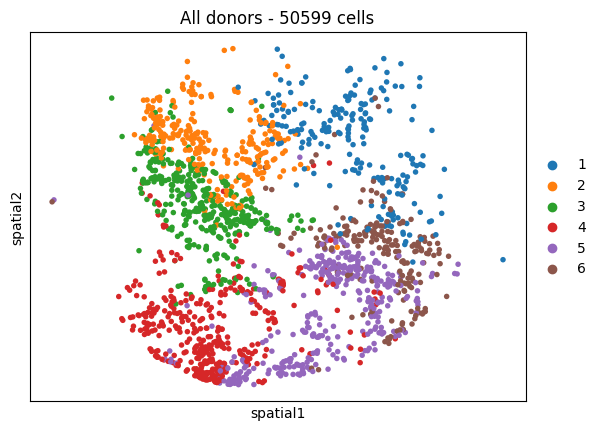

In [71]:
# plot donrowith min raw trait
sc.pl.embedding(adata[adata.obs["m1_z1_raw_trait"] == df_meta["m1_z1_raw_trait"].min()], basis="spatial", color=["ct_for_deg"], title=f"All donors - {adata.shape[0]} cells")
sc.pl.embedding(adata[adata.obs["m1_z1_raw_trait"] == df_meta["m1_z1_raw_trait"].min()], basis="spatial", color=["zone"], title=f"All donors - {adata.shape[0]} cells")

# Download from bucket vcf (already normalised in this case)

```bash
gsutil -m cp 
gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Updated_Objects/vcfs/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz 
gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Updated_Objects/vcfs/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz.tbi 
.
```

# Install bcftools podman 

To call container one command at a time
```bash
podman run \
    --rm \
    -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data \
    quay.io/biocontainers/bcftools:1.21--h8b25389_0 \
    ... command ...
```

```bash
# lisg header of vs f
    bcftools view -h /data/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz
# list donros
    bcftools query -l /data/gvs_concat_outputs_2026-04-24.donors_renamed_filtered_norm.vcf.gz
```

# Prepare VCF files

In [ ]:
VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/BICAN/vcf"

RAW_VCF  = "whole_bican_raw/raw.vcf.gz"   
RAW_TBI  = "whole_bican_raw/raw.vcf.gz.tbi"

NORM_VCF = "whole_bican_norm/norm.vcf.gz"
NORM_TBI      = "whole_bican_norm/norm.vcf.gz.tbi"

GENES_BED = ["MSH3", "PMS2"]
BED = "subset/genes.bed"
GENOME = "GRCh38"
FLANK = 20000 # ±20 kb around each gene (regulatory + nearby modifier variants)

# bith by gene and samples
SUBSET_VCF = "subset/candidate.vcf.gz"

SUBSET_NORM_VCF = "subset/candidate.norm.vcf.gz"
SUBSET_NORM_TBI = "subset/candidate.norm.vcf.gz.tbi"

SUBSET_PGEN = "subset/plink/candidate"

PCA = "whole_bican_PCA"
SUBSET_FOR_NORM_PCA = "subset/for_PCA/vcf_pca.norm.vcf.gz"
SUBSET_PGEN_PCA = "subset/for_PCA/vcf_pca"
SUBSET_PGEN_PCA_QC = "subset/for_PCA/vcf_pca_qc"
SUBSET_PCs = "subset/for_PCA/PCA"
N_PCs = 10

MOUNT = VCF_FOLDER
IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"

### *) Build the .bed file

file contianing the coodirnted of the 2 genes ( + 20Kb pairs flanks) inside which we want to study the SNPs

In [ ]:
# Chekc how the chr stirng are formatted --< same must be in .bed file
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools view -h {NORM_VCF}'
print(cmd)
!{cmd} | grep "^##contig" | head

# ATTENTION:  GRCh38  == assembly=38

podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools view -h norm.vcf.gz


##contig=<ID=chr1,length=248956422,assembly=38>
##contig=<ID=chr2,length=242193529,assembly=38>
##contig=<ID=chr3,length=198295559,assembly=38>
##contig=<ID=chr4,length=190214555,assembly=38>
##contig=<ID=chr5,length=181538259,assembly=38>
##contig=<ID=chr6,length=170805979,assembly=38>
##contig=<ID=chr7,length=159345973,assembly=38>
##contig=<ID=chr8,length=145138636,assembly=38>
##contig=<ID=chr9,length=138394717,assembly=38>
##contig=<ID=chr10,length=133797422,assembly=38>
grep: write error: Broken pipe
Error: attaching to container 333929fad17e5652abab90c33cbdc5b839d38761b687853fbd718762a048e78d: write /dev/stdout: broken pipe


In [98]:
# very where the 2 genes are in the geinome
# ATTENTION the genome msut be the same used for normalisation

# Ensembl REST API (GRCh38) — gives exact gene coordinates
import requests

def gene_coords(symbol, build):
    server = "https://rest.ensembl.org" if build == "GRCh38" else "https://grch37.rest.ensembl.org"
    r = requests.get(f"{server}/lookup/symbol/homo_sapiens/{symbol}",
                     headers={"Content-Type": "application/json"})
    r.raise_for_status()
    d = r.json()
    return d["seq_region_name"], d["start"], d["end"], d["assembly_name"]

df_bed = pd.DataFrame(columns=["gene", "chrom", "start", "end", "assembly"])
for g in GENES_BED:
    chrom, start, end, asm = gene_coords(g, GENOME)
    assert asm.startswith(GENOME), f"{g} returned {asm}, not {GENOME}!"
    start = max(0, start - 1 - FLANK) #add flanks; BED start is 0-based, Ensembl start is 1-based -> subtract 1
    end = end + FLANK
    name_chr = "chr" + chrom
    df_bed = pd.concat([df_bed, pd.DataFrame([{"gene": g, "chrom": name_chr, "start": start, "end": end, "assembly": asm}])], ignore_index=True)

df_bed = df_bed.sort_values(["chrom", "start"]).reset_index(drop=True)
df_bed[["chrom", "start", "end", "gene"]].to_csv(
    f"{VCF_FOLDER}/{BED}", sep="\t", header=False, index=False
)

df_bed

,gene,chrom,start,end,assembly
0,MSH3,chr5,80634612,80900295,GRCh38
1,PMS2,chr7,5950924,6029130,GRCh38


### *) Fins intersetions amples

In [126]:
# find samples in both adata and vcf
samples_in_adata = adata.obs["donor_id"].unique().tolist()
samples_in_vcf = !podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools query -l {NORM_VCF}   

samples_intersection = list(set(samples_in_adata).intersection(set(samples_in_vcf)))
samples_intersection

['UMBEB24013',
 'UMBEB23127',
 'MD6927',
 'MD9162',
 'MS913848',
 'UMBEB23073',
 'MS30499',
 'MD9129',
 'UMBEB23033',
 'MS986638',
 'UMBEB22074',
 'UMBEB23158',
 'MS876075',
 'MS706984',
 'MD9261',
 'UMBEB23076',
 'PT13935']

### Create subsetted vcf based on 1)interestign genes 2) samples

In [ ]:
# subset adata
adata = adata[adata.obs["donor_id"].isin(samples_intersection), :].copy()  # keep only donors that are in the VCF

# subset samples in vcf
    # 1) sampoles interstiosn
    # 2) selected genes
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools view -R {BED} -s {",".join(samples_intersection)} {RAW_VCF} -Oz -o {SUBSET_VCF}'
print(cmd)
!{cmd}


podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools view -R subset/genes.bed -s UMBEB24013,UMBEB23127,MD6927,MD9162,MS913848,UMBEB23073,MS30499,MD9129,UMBEB23033,MS986638,UMBEB22074,UMBEB23158,MS876075,MS706984,MD9261,UMBEB23076,PT13935 whole_bican_norm/norm.vcf.gz -Oz -o subset/candidate.vcf.gz
[W::hts_idx_load3] The index file is older than the data file: whole_bican_norm/norm.vcf.gz.tbi


### Normalise Sbseeted version

Attention: need to have genome fasta 
```bash
gsutil cp gs://gcp-public-data--broad-references/hg38/v0/Homo_sapiens_assembly38.fasta .
mv Homo_sapiens_assembly38.fasta GRCh38.fasta
```

In [133]:
# Normalise: left-align, split multiallelics
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools norm -f fasta_genome/{GENOME}.fasta -m -any {SUBSET_VCF} -Oz -o {SUBSET_NORM_VCF}'
print(cmd)
!{cmd}

# Index the result 
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools index -t -f {SUBSET_NORM_VCF}'
print(cmd)
!{cmd}

podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools norm -f fasta_genome/GRCh38.fasta -m -any subset/candidate.vcf.gz -Oz -o subset/candidate.norm.vcf.gz
Lines   total/split/joined/realigned/removed/skipped:	5574/0/0/0/0/0
podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/bcftools:1.21--h8b25389_0 bcftools index -t -f subset/candidate.norm.vcf.gz


### Convert to plink file format

In [139]:
VCF_FOLDER + "/" + SUBSET_PGEN.rsplit("/", 1)[0]

'/home/gdallagl/myworkdir/XDP/data/BICAN/vcf/subset/plink'

In [142]:
os.makedirs(VCF_FOLDER + "/" + SUBSET_PGEN.rsplit("/", 1)[0], exist_ok=True)  # create the plink folder if it doesn't exist
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
  plink2 --vcf {SUBSET_VCF} --make-pgen --out {SUBSET_PGEN} --threads 4'
print(cmd)
!{cmd}

podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0   plink2 --vcf subset/candidate.vcf.gz --make-pgen --out subset/plink/candidate --threads 4
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/plink/candidate.log.
Options in effect:
  --make-pgen
  --out subset/plink/candidate
  --threads 4
  --vcf subset/candidate.vcf.gz

Start time: Fri Jun 26 15:01:10 2026
314189 MiB RAM detected, ~282969 available; reserving 157094 MiB for main
workspace.
Using up to 4 compute threads.
--vcf: 5574 variants scanned.
--vcf: subset/plink/candidate-temporary.pgen +
subset/plink/candidate-temporary.pvar.zst +
subset/plink/candidate-temporary.psam written.
17 samples (0 females, 0 males, 17 ambiguous; 17 founders) loaded from
subset/plink/candidate-temporary.psam.
5574 variants loaded from subset/plink/

### QC pgen file

In [143]:
cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
  plink2 --pfile {SUBSET_PGEN} \
  --geno 0.05 \
  --mind 0.1 \
  --maf 0.05 \
  --make-pgen --out {SUBSET_PGEN}_qc'
print(cmd)
!{cmd}

podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0   plink2 --pfile subset/plink/candidate   --geno 0.05   --mind 0.1   --maf 0.05   --make-pgen --out subset/plink/candidate_qc
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/plink/candidate_qc.log.
Options in effect:
  --geno 0.05
  --maf 0.05
  --make-pgen
  --mind 0.1
  --out subset/plink/candidate_qc
  --pfile subset/plink/candidate

Start time: Fri Jun 26 15:01:31 2026
314189 MiB RAM detected, ~282929 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
17 samples (0 females, 0 males, 17 ambiguous; 17 founders) loaded from
subset/plink/candidate.psam.
5574 variants loaded from subset/plink/candidate.pvar.
Note: No phenotype data present.
Calculating sample missingness rates... 

### *) Calcualte PCs (on ALL snps and ALL samples)

dont use XY chr


In [163]:
long_range_ld = """chr1 47761740 51761740 LRLD1
chr2 85919365 100517106 LRLD2
chr2 182427027 189427029 LRLD3
chr3 47483505 49987563 LRLD4
chr3 83368158 86868160 LRLD5
chr5 44464140 51168409 LRLD6
chr5 129636407 132636409 LRLD7
chr6 25391792 33424245 LRLD8
chr6 57788603 64333333 LRLD9
chr6 139637169 142137170 LRLD10
chr7 54964812 66897578 LRLD11
chr8 8105067 12105082 LRLD12
chr8 43025699 50924888 LRLD13
chr8 110918594 113918595 LRLD14
chr10 36671065 43184546 LRLD15
chr11 88127183 91127184 LRLD16
chr12 32955798 41319931 LRLD17
chr20 33948532 36438183 LRLD18
"""
with open("/home/gdallagl/myworkdir/XDP/data/BICAN/vcf/fasta_genome/long_range_ld_GRCh38.txt", "w") as f:
    f.write(long_range_ld)

In [169]:
PCA_PGEN = "whole_bican_PCA/vcf_pca"
PCA_PGEN_NORM = "whole_bican_PCA/vcf_pca_norm"
PCA_PGEN_NORM_PRUNED = "whole_bican_PCA/vcf_pca_norm_pruned"
SUBSET_PCs = "whole_bican_PCA/PCA"
N_PCs = 10

In [185]:
# make-pgen on full cohort altedy nromalised, with unique IDs (still needed!)
print("Making pgen for PCA...")
cmd = f"""
    podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
    plink2 --vcf {NORM_VCF} \
    --autosome \
    --set-all-var-ids '@:#:$r:$a' \
    --new-id-max-allele-len 100 missing \
    --make-pgen --out {PCA_PGEN} --threads 4"""
print(cmd)
!{cmd}

# qc plink
print("QC pgen for PCA...")
cmd = f"""
    podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
    plink2 --pfile {PCA_PGEN} \
    --geno 0.05 \
    --maf 0.05 \
    --make-pgen --out {PCA_PGEN_NORM}"""
print(cmd)
!{cmd}

# LD pruning (remove other SNPs that could be deletions for PCA)
print("LD pruning...")
cmd = f"""
    podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
    plink2 --pfile {PCA_PGEN_NORM} \
    --maf 0.05 --geno 0.02 --hwe 1e-6 \
    --rm-dup exclude-all \
    --exclude range fasta_genome/long_range_ld_GRCh38.txt \
    --indep-pairwise 200 50 0.2 --out {PCA_PGEN_NORM_PRUNED}"""
print(cmd)
!{cmd}

# Compute PCA
print("Computing PCA...")
cmd = f"""
    podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
    plink2 --pfile {PCA_PGEN_NORM} \
    --extract {PCA_PGEN_NORM_PRUNED}.prune.in \
    --maf 0.05 --geno 0.02 --hwe 1e-6 \
    --pca 10 --out {SUBSET_PCs}"""
print(cmd)
!{cmd}

Making pgen for PCA...

    podman run --rm -w /data -v /home/gdallagl/myworkdir/XDP/data/BICAN/vcf:/data quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0     plink2 --vcf whole_bican_norm/norm.vcf.gz     --autosome     --set-all-var-ids '@:#:$r:$a'     --new-id-max-allele-len 100 missing     --make-pgen --out whole_bican_PCA/vcf_pca --threads 4


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to whole_bican_PCA/vcf_pca.log.
Options in effect:
  --autosome
  --make-pgen
  --new-id-max-allele-len 100 missing
  --out whole_bican_PCA/vcf_pca
  --set-all-var-ids @:#:$r:$a
  --threads 4
  --vcf whole_bican_norm/norm.vcf.gz

Start time: Fri Jun 26 17:25:47 2026
314189 MiB RAM detected, ~282392 available; reserving 157094 MiB for main
workspace.
Using up to 4 compute threads.
--vcf: 42107675 variants scanned (1619076 skipped).
--vcf: whole_bican_PCA/vcf_pca-temporary.pgen +
whole_bican_PCA/vcf_pca-temporary.pvar.zst +
whole_bican_PCA/vcf_pca-temporary.psam written.
289 samples (0 females, 0 males, 289 ambiguous; 289 founders) loaded from
whole_bican_PCA/vcf_pca-temporary.psam.
length.
42107675 variants loaded from whole_bican_PCA/vcf_pca-temporary.pvar.zst.
Note: No phenotype data present.
Writing whole_bican_PCA/vcf_p

In [ ]:
# # select only commons smaples
# print("Selecting only common samples for PCA...")
# cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools view --threads 4-s {",".join(samples_intersection)} {RAW_VCF} -Oz -o {SUBSET_FOR_PCA}'
# print(cmd)
# !{cmd}

# # qc
# print("\nNormalising for PCA...")
# cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_BCFTOOLS} bcftools norm -f fasta_genome/{GENOME}.fasta -m -any {SUBSET_FOR_PCA} -Oz -o {SUBSET_FOR_NORM_PCA}'
# print(cmd)
# !{cmd}

# # Plink conversion
# print("\nConverting to plink format for PCA...")
# cmd = f"""podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
#   plink2 --vcf {SUBSET_FOR_NORM_PCA} --make-pgen \
#   --autosome \
#   --set-all-var-ids '@:#:$r:$a' \
#   --out {SUBSET_PGEN_PCA} --threads 4"""
# print(cmd)
# !{cmd}

# # qc plink
# print("\nQC for PCA...")
# cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
#   plink2 --pfile {SUBSET_PGEN_PCA} \
#          --maf 0.05 --geno 0.02 \
#          --hwe 1e-6 \
#          --exclude range fasta_genome/long_range_ld_GRCh38.txt \
#          --bad-ld \
#          --indep-pairwise 200 50 0.2 --out {SUBSET_PGEN_PCA_QC}'
# print(cmd)
# !{cmd}

# # compute PCs
# print("\nComputing PCA...")
# cmd = f'podman run --rm -w /data -v {MOUNT}:/data {IMAGE_PLINK} \
#         plink2 --pfile {SUBSET_PGEN_PCA} \
#                --extract {SUBSET_PGEN_PCA_QC}.prune.in \
#                --maf 0.05 --geno 0.02 --hwe 1e-6 \
#                --pca {N_PCs} --out {SUBSET_PCs}'
# print(cmd)
# !{cmd}

,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,MS437537,-0.022986,0.035126,-0.095227,0.013472,-0.058389,-0.060290,0.063246,0.003417,0.065666,-0.036396
1,MS614721,-0.043512,0.030190,-0.081985,0.017517,-0.068311,0.012097,-0.126309,-0.077691,-0.013099,0.059940
2,MS722238,0.031581,-0.019158,0.008531,0.105667,-0.008539,0.001865,-0.006769,-0.006450,-0.001904,0.002843
3,MD5334,0.009284,0.232155,-0.259975,-0.053185,-0.003355,0.019297,0.049399,-0.033014,-0.032350,-0.013673
4,MS107236,0.006846,0.053931,-0.117680,0.019984,-0.001945,-0.038359,-0.015935,0.021513,0.021869,-0.001382
...,...,...,...,...,...,...,...,...,...,...,...
284,PT13904,-0.120775,-0.020671,0.010046,-0.003778,0.046186,0.001481,-0.038138,0.179059,0.026953,-0.059009
285,PT13892,0.037701,-0.025414,0.010081,-0.045300,0.005666,0.005814,0.019031,-0.015934,0.004209,0.020274
286,MS581663,-0.139360,-0.023427,0.012339,0.001135,0.041954,0.104950,-0.022960,0.025367,-0.049557,-0.021988
287,PT13923,0.038117,-0.020360,0.011421,-0.040022,-0.001609,-0.005628,-0.004411,0.003229,-0.015035,0.011961


,0,PC
1,16.27300,PC1
2,3.28841,PC2
3,1.59846,PC3
4,1.39058,PC4
5,1.16462,PC5
6,1.15779,PC6
7,1.15657,PC7
8,1.14451,PC8
9,1.14294,PC9
10,1.14047,PC10


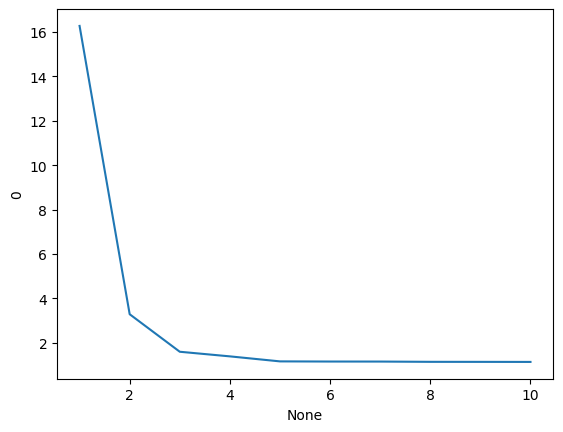

In [187]:
# df_pcs = pd.read_csv(f"{VCF_FOLDER}/{SUBSET_PCs}.eigenvec", delim_whitespace=True, header=None)
# df_pcs_var = pd.read_csv(f"{VCF_FOLDER}/{SUBSET_PCs}.eigenval", delim_whitespace=True, header=None)

pcs = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/BICAN/vcf/whole_bican_PCA/PCA.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]   # header like #FID IID PC1 PC2 ...
display(pcs)

explained_variance = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/BICAN/vcf/whole_bican_PCA/PCA.eigenval", sep=r"\s+", header=None)
explained_variance.index = explained_variance.index + 1
explained_variance["PC"] = "PC" + explained_variance.index.astype(str)
sns.lineplot(data=explained_variance, x=explained_variance.index, y=0)
explained_variance


### Create cov file for plink

In [245]:
# Whole bicna etadata
bican_metatadata = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_metadata.csv", index_col=0).drop_duplicates("donor_id").set_index("donor_id")[["age", "imputed_sex"]]
sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
if bican_metatadata["imputed_sex"].dtype == object:
    bican_metatadata["imputed_sex"] = bican_metatadata["imputed_sex"].map(sex_map)
bican_metatadata.rename(columns={"imputed_sex": "sex"}, inplace=True)
display(bican_metatadata.head())

# pcs
df_meta_plink = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/BICAN/vcf/whole_bican_PCA/vcf_pca.psam", sep=r"\s+").drop(columns=["SEX"])  # drop PHENO column
df_meta_plink.columns = [c.lstrip("#") for c in df_meta_plink.columns]   # strip leading # from header
df_meta_plink["FID"] = 0
display(df_meta_plink)

# subset bican with trait metadat
display(df_meta)

# ocs
display(pcs)

,age,sex
donor_id,,
MD6366,31,2
MD6417,46,1
MD6424,55,1
MD6429,27,1
MD6432,28,2


,IID,FID
0,MS437537,0
1,MS614721,0
2,MS722238,0
3,MD5334,0
4,MS107236,0
...,...,...
284,PT13904,0
285,PT13892,0
286,MS581663,0
287,PT13923,0


,experiment,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,
PT13935,s5,0.204653,-0.500904,0.260784,3396.0
UMBEB23073,s12,0.271071,1.063244,0.230906,2800.0
UMBEB23033,s15,0.205100,-0.350415,0.252199,2745.0
UMBEB23076,s16,0.213597,-0.207504,0.317406,1971.0
MS706984,s17,0.101388,-1.821749,0.198381,1657.0
MS913848,s18,0.224756,0.068729,0.257732,1228.0
UMBEB22074,s20,0.284892,1.346683,0.393701,695.0
UMBEB23127,s21,0.213759,-0.068729,0.262857,1628.0
MS9244,s23,0.254292,0.663752,0.204327,5242.0


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,MS437537,-0.022986,0.035126,-0.095227,0.013472,-0.058389,-0.060290,0.063246,0.003417,0.065666,-0.036396
1,MS614721,-0.043512,0.030190,-0.081985,0.017517,-0.068311,0.012097,-0.126309,-0.077691,-0.013099,0.059940
2,MS722238,0.031581,-0.019158,0.008531,0.105667,-0.008539,0.001865,-0.006769,-0.006450,-0.001904,0.002843
3,MD5334,0.009284,0.232155,-0.259975,-0.053185,-0.003355,0.019297,0.049399,-0.033014,-0.032350,-0.013673
4,MS107236,0.006846,0.053931,-0.117680,0.019984,-0.001945,-0.038359,-0.015935,0.021513,0.021869,-0.001382
...,...,...,...,...,...,...,...,...,...,...,...
284,PT13904,-0.120775,-0.020671,0.010046,-0.003778,0.046186,0.001481,-0.038138,0.179059,0.026953,-0.059009
285,PT13892,0.037701,-0.025414,0.010081,-0.045300,0.005666,0.005814,0.019031,-0.015934,0.004209,0.020274
286,MS581663,-0.139360,-0.023427,0.012339,0.001135,0.041954,0.104950,-0.022960,0.025367,-0.049557,-0.021988
287,PT13923,0.038117,-0.020360,0.011421,-0.040022,-0.001609,-0.005628,-0.004411,0.003229,-0.015035,0.011961


In [246]:
df_meta_gwas = df_meta.copy()
df_meta_gwas = pd.merge(df_meta_gwas, bican_metatadata, left_index=True, right_index=True, how="left")
df_meta_gwas = pd.merge(df_meta_gwas, df_meta_plink.set_index("IID"), left_index=True, right_index=True, how="left")
df_meta_gwas = pd.merge(df_meta_gwas, pcs.set_index("IID"), left_index=True, right_index=True, how="left")

df_meta_gwas = df_meta_gwas.dropna()
df_meta_gwas["IID"] = df_meta_gwas.index

df_meta_gwas

,experiment,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,age,sex,FID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,IID
donor_id,,,,,,,,,,,,,,,,,,,
PT13935,s5,0.204653,-0.500904,0.260784,3396.0,44.0,1.0,0.0,-0.093010,-0.028734,0.016345,-0.014483,-0.148745,0.028757,0.034207,-0.137084,0.051394,0.176666,PT13935
UMBEB23073,s12,0.271071,1.063244,0.230906,2800.0,36.0,1.0,0.0,-0.109115,-0.022624,0.013537,-0.014091,0.051905,-0.183010,0.125992,0.013670,0.126367,0.184136,UMBEB23073
UMBEB23033,s15,0.205100,-0.350415,0.252199,2745.0,64.0,1.0,0.0,0.030000,-0.014006,0.001979,0.026884,-0.002684,0.016482,0.005414,0.001470,-0.002281,0.024253,UMBEB23033
UMBEB23076,s16,0.213597,-0.207504,0.317406,1971.0,66.0,1.0,0.0,-0.127084,-0.027953,0.021961,-0.010072,-0.043823,0.134732,-0.042077,0.028385,-0.100410,-0.082954,UMBEB23076
MS706984,s17,0.101388,-1.821749,0.198381,1657.0,76.0,2.0,0.0,0.039251,-0.025038,0.008707,-0.042940,-0.022155,0.020268,0.009604,0.006692,-0.000073,0.026911,MS706984
UMBEB22074,s20,0.284892,1.346683,0.393701,695.0,60.0,1.0,0.0,0.025321,-0.014344,-0.007618,0.045856,0.025235,-0.007453,-0.019057,0.001896,-0.009048,-0.001731,UMBEB22074
MS30499,s26,0.171344,-0.663752,0.233645,2352.0,71.0,1.0,0.0,0.038150,-0.018458,0.012084,0.014591,0.015195,0.009459,-0.018186,-0.005762,-0.001843,-0.001021,MS30499
MD9129,s29,0.254003,0.500904,0.311765,1374.0,54.0,1.0,0.0,0.039650,-0.023797,0.005344,-0.043098,0.002654,-0.002161,0.007670,0.012747,-0.005065,0.011371,MD9129
MD9162,s31,0.305556,1.821749,0.348485,4140.0,45.0,1.0,0.0,0.039338,-0.025099,0.008861,-0.036514,-0.001111,0.003625,0.005357,-0.003824,-0.010490,0.000380,MD9162


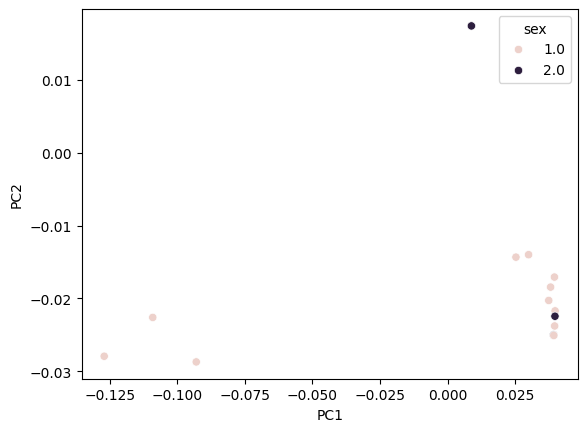

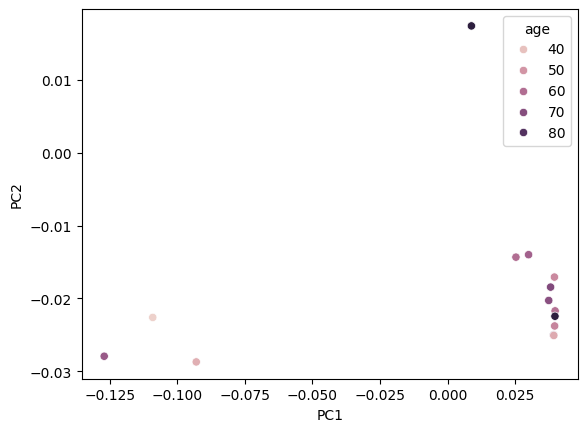

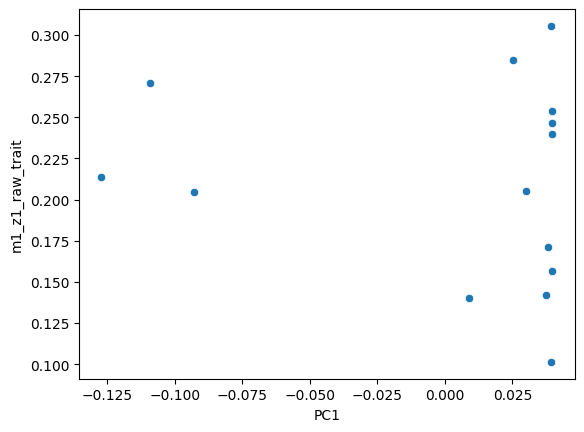

In [247]:
sns.scatterplot(data=df_meta_gwas, x="PC1", y="PC2", hue="sex"); plt.show()
sns.scatterplot(data=df_meta_gwas, x="PC1", y="PC2", hue="age"); plt.show()
sns.scatterplot(data=df_meta_gwas, x="PC1", y="m1_z1_raw_trait"); plt.show()

In [248]:
TRAIT = "m1_z1_trait"
COVS = ["d1d1_z2_cov", "age", "sex", "PC1", "PC2", "PC3"]
PHENO_FILE = "subset/gwas_input_covs/pheno.txt"
COVAR_FILE = "subset/gwas_input_covs/covar.txt"

pheno = df_meta_gwas[["IID", TRAIT]]
pheno.to_csv(f"{VCF_FOLDER}/{PHENO_FILE}", sep="\t", index=False, na_rep="NA")

covar_cols = ["IID"] + COVS
covar = df_meta_gwas[covar_cols]
covar.to_csv(f"{VCF_FOLDER}/{COVAR_FILE}", sep="\t", index=False, na_rep="NA")

# Run GWAS

In [ ]:
TRAIT = "m1_z1_trait"
COVS = ["d1d", "age", "sex", "PC1", "PC2", "PC3", "PC4"]

In [ ]:
cmd = f"""
    plink2 --pfile cand_qc \
    --pheno pheno.txt --pheno-name shape_rint \
    --covar covar.txt --covar-name eSPN,age,sex,PC1,PC2,PC3,PC4 \
    --glm hide-covar \
    --covar-variance-standardize \
    --out assoc_primary
  """
#    --extract candidate_snps.txt \   # your few named modifier SNPs
